# Who will withdraw, and when can we know? An honest early-warning system for OULAD (v2)

**Version 1** of this project (February 2026) trained a Random Forest on the Open University Learning
Analytics Dataset and reported ROC-AUC 0.895, plus a headline finding: students who never submit an
assessment withdraw at 79.5%. This notebook asks whether those numbers survive scrutiny, and then
builds the version a university could actually use.

The question a tutor can act on is not "who withdraws by the end?" but **"on day *k* of the module,
among students still enrolled, who is most likely to leave, using only what we can see before day
*k*?"**. Everything below follows from taking that sentence literally.

**Plan**
1. Data and the unit of analysis
2. Auditing v1: how much of 0.895 was real?
3. When do students leave? (survival analysis)
4. Early warning on day *k*: models, the earliness-accuracy trade-off, calibration, capacity
5. Who gets flagged: error rates across groups
6. Module effects, adjusted for who enrols
7. Conclusions, limits and the numbers worth quoting

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import oulad_ew as ew  # noqa: E402

DATA, FIG = ROOT / "data", ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SEED = 20261007
R = {}  # every number quoted in the README is written here and saved to results/metrics.json
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
INK, ACCENT, WARM, GREY = "#1F3A5F", "#2A9D8F", "#C8553D", "#8A8A8A"


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / name, bbox_inches="tight")

## 1. Data and the unit of analysis

OULAD (Kuzilek, Hlosta and Zdrahal, 2017; CC BY 4.0) covers 22 presentations of 7 modules at the
Open University in 2013 and 2014. `scripts/get_data.py` fetches the 454 MB click log from the UCI
repository (the Open University's own link now returns 404) and checks that the six committed tables
match the archive row for row.

The unit is an **enrolment**: one student in one module presentation. v1 called its 32,593 rows
"students"; they are enrolments.

In [2]:
T = ew.load(DATA)
enrol_all = T["enrol"]
enrol, dropped = ew.clean_enrolments(enrol_all)
daily = ew.daily_clicks(DATA, T["vle"])

R["enrolments"] = len(enrol_all)
R["students"] = int(enrol_all["id_student"].nunique())
R["presentations"] = int(enrol_all[ew.PRESENTATION].drop_duplicates().shape[0])
R["withdrawn_rate_all"] = float(enrol_all["withdrawn"].mean())
R.update({"dropped_" + k: v for k, v in dropped.items()})
R["enrolments_kept"] = len(enrol)
with open(DATA / "studentVle.csv") as fh:
    R["click_rows"] = sum(1 for _ in fh) - 1
print(f"click log: {R['click_rows']:,} rows (student x page x day)")
print(f"{R['enrolments']:,} enrolments held by {R['students']:,} students in {R['presentations']} presentations")
print(enrol_all["final_result"].value_counts().to_string())
print(f"withdrawn: {R['withdrawn_rate_all']:.1%}; dropped for unknowable or contradictory timing: {dropped}")
print(f"daily click rows (enrolment x day): {len(daily):,}")

click log: 10,655,280 rows (student x page x day)
32,593 enrolments held by 28,785 students in 22 presentations
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
withdrawn: 31.2%; dropped for unknowable or contradictory timing: {'withdrawn_without_date': 93, 'unregistered_but_not_withdrawn': 9}
daily click rows (enrolment x day): 1,808,119


102 enrolments are set aside: 93 withdrawals with no withdrawal date (we cannot tell when they could
have been flagged) and 9 enrolments that unregistered yet are recorded as "Fail". Everything in
Sections 3 to 6 uses the remaining 32,491.

## 2. Auditing v1: how much of 0.895 was real?

v1's features were computed over the whole course and then used to predict whether the student
withdrew. A student who leaves in week 3 cannot submit the week-10 assessment, so "number of
assessments submitted" partly *records* the withdrawal instead of predicting it. Two further problems
turned up when re-reading the code:

- **Cross-enrolment mixing.** Assessment features were grouped by `id_student` alone and merged back
  onto every enrolment of that student, so one enrolment's features included scores from the student's
  *other* modules, some of them in later presentations.
- **The split.** A random row split can put the same student in the training and the test set.

The ladder below changes one thing at a time, using v1's own model (Random Forest, 100 trees,
class-balanced) throughout so that only the data change.

In [3]:
def v1_frame(per_enrolment: bool) -> pd.DataFrame:
    """v1's feature table, rebuilt line for line from its notebook (cells 4-5 and 26)."""
    info = T["studentInfo"].copy()
    info["churned"] = (info["final_result"] == "Withdrawn").astype(int)
    info["imd_band"] = info["imd_band"].fillna("Unknown")
    for col in ["gender", "region", "highest_education", "imd_band", "age_band", "disability"]:
        info[col + "_encoded"] = LabelEncoder().fit_transform(info[col])
    info = info.merge(T["studentRegistration"], on=ew.KEYS, how="left")
    sa = T["studentAssessment"]
    if per_enrolment:
        sa = sa.merge(T["assessments"][["id_assessment"] + ew.PRESENTATION], on="id_assessment")
        keys = ew.KEYS
    else:
        keys = ["id_student"]
    agg = sa.groupby(keys).agg(avg_score=("score", "mean"), num_assessments=("id_assessment", "count"),
                               avg_submission_day=("date_submitted", "mean")).reset_index()
    info = info.merge(agg, on=keys, how="left")
    info["date_registration"] = info["date_registration"].fillna(0)
    info["avg_score"] = info["avg_score"].fillna(-1)
    info["num_assessments"] = info["num_assessments"].fillna(0)
    info["avg_submission_day"] = info["avg_submission_day"].fillna(-1)
    info["never_submitted"] = (info["num_assessments"] == 0).astype(int)
    return info


V1_FEATURES = ["gender_encoded", "region_encoded", "highest_education_encoded", "imd_band_encoded", "age_band_encoded",
               "num_of_prev_attempts", "studied_credits", "disability_encoded", "date_registration", "avg_score",
               "num_assessments", "avg_submission_day", "never_submitted"]


def rf():
    return RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced", n_jobs=-1)


def auc_of(train, test, features, model):
    model.fit(train[features], train["churned"])
    return roc_auc_score(test["churned"], model.predict_proba(test[features])[:, 1])


v1s, v1e = v1_frame(per_enrolment=False), v1_frame(per_enrolment=True)
ladder = []
tr, te = train_test_split(v1s, test_size=0.2, random_state=42, stratify=v1s["churned"])
ladder.append(("A. v1 as published: features per student, random row split", auc_of(tr, te, V1_FEATURES, rf())))
overlap = len(set(tr["id_student"]) & set(te["id_student"]))
tr, te = train_test_split(v1e, test_size=0.2, random_state=42, stratify=v1e["churned"])
ladder.append(("B. features per enrolment (no mixing across modules)", auc_of(tr, te, V1_FEATURES, rf())))
gi = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(v1e, groups=v1e["id_student"]))
ladder.append(("C. B, split by student", auc_of(v1e.iloc[gi[0]], v1e.iloc[gi[1]], V1_FEATURES, rf())))
TEST_PRES = "2014J"
is_test = v1e["code_presentation"] == TEST_PRES
ladder.append(("D. B, train on 2013B-2014B, test on 2014J", auc_of(v1e[~is_test], v1e[is_test], V1_FEATURES, rf())))
for name, a in ladder:
    print(f"{a:.3f}  {name}")
print(f"students in both halves of v1's random split: {overlap:,}")
R["v1_auc_reproduced"] = ladder[0][1]
R["v1_students_in_both_splits"] = overlap

0.896  A. v1 as published: features per student, random row split
0.932  B. features per enrolment (no mixing across modules)
0.932  C. B, split by student
0.942  D. B, train on 2013B-2014B, test on 2014J
students in both halves of v1's random split: 1,121


**Reading the ladder.** v1's number reproduces (0.896). Fixing the two bugs makes the score go *up*,
to 0.932 and then 0.942 on a future cohort. That is the tell: computing the whole-course features
correctly, per enrolment, only sharpens how precisely they describe each enrolment's own ending. 1,121
students sat in both halves of v1's random split, but separating them changes nothing here, because
the leak is in time, not in identity.

Rows A to D all contain the same leak. The honest rung needs features that exist on a given day; it is
built in Section 4 and added to this ladder there.

First, the leak itself. For students who withdrew, plot how many assessments they submitted against
the day they withdrew.

correlation between withdrawal day and assessments submitted: 0.72


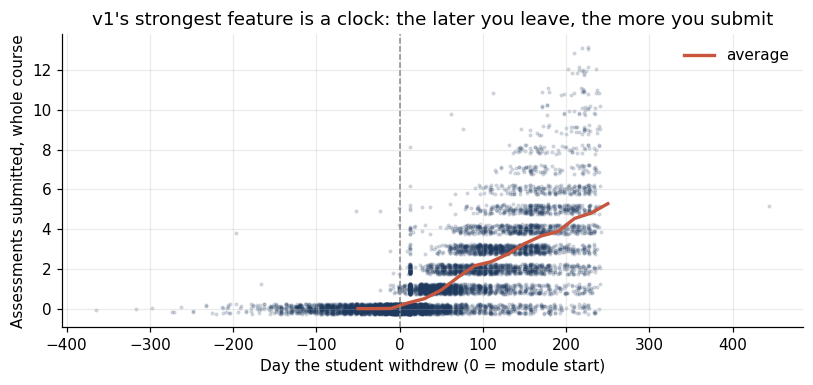

In [4]:
w = v1e[v1e["churned"] == 1].dropna(subset=["date_unregistration"])
bins = np.arange(-60, 280, 20)
w["bin"] = pd.cut(w["date_unregistration"], bins)
med = w.groupby("bin")["num_assessments"].agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.scatter(w["date_unregistration"], w["num_assessments"] + np.random.default_rng(1).uniform(-0.25, 0.25, len(w)),
           s=3, alpha=0.15, color=INK)
ax.plot([b.mid for b in med.index], med["mean"], color=WARM, lw=2.2, label="average")
ax.axvline(0, color=GREY, ls="--", lw=1)
ax.set_xlabel("Day the student withdrew (0 = module start)")
ax.set_ylabel("Assessments submitted, whole course")
ax.set_title("v1's strongest feature is a clock: the later you leave, the more you submit")
ax.legend(frameon=False)
save(fig, "leak_mechanism.png")
R["corr_withdrawal_day_num_assessments"] = float(w[["date_unregistration", "num_assessments"]].corr().iloc[0, 1])
print(f"correlation between withdrawal day and assessments submitted: {R['corr_withdrawal_day_num_assessments']:.2f}")

A correlation of 0.72 between *when* a student left and *how many* assessments they handed in: the
feature is largely a clock that stops at withdrawal. A model trained on it learns "students who left
early handed in little", which is true and useless for prediction.

### The 79.5% "never submitted" finding

If a student withdraws before the first assessment is even due, "never submitted" is a consequence of
leaving, not a warning sign.

In [5]:
first_due = (T["assessments"][T["assessments"]["assessment_type"] != "Exam"]
             .groupby(ew.PRESENTATION)["date"].min().rename("first_due").reset_index())
ns = v1e.merge(first_due, on=ew.PRESENTATION, how="left")
never = ns[ns["never_submitted"] == 1]
R["v1_never_submitted_students"] = int((v1s["never_submitted"] == 1).sum())
R["v1_never_submitted_withdrawn_share"] = float(v1s.loc[v1s["never_submitted"] == 1, "churned"].mean())
R["never_submitted_enrolments"] = len(never)
R["never_submitted_withdrawn_share"] = float(never["churned"].mean())
wd = never[never["churned"] == 1]
R["never_submitted_left_before_first_due"] = float((wd["date_unregistration"] < wd["first_due"]).mean())
R["never_submitted_left_before_day0"] = float((wd["date_unregistration"] < 0).mean())
print(f"v1 (per student): {R['v1_never_submitted_students']:,} never submitted; {R['v1_never_submitted_withdrawn_share']:.1%} withdrew")
print(f"per enrolment: {R['never_submitted_enrolments']:,} never submitted; {R['never_submitted_withdrawn_share']:.1%} withdrew")
print(f"of those who withdrew, {R['never_submitted_left_before_first_due']:.1%} left before their first assessment was due, "
      f"{R['never_submitted_left_before_day0']:.1%} before the module started")

v1 (per student): 5,847 never submitted; 79.5% withdrew
per enrolment: 6,750 never submitted; 80.9% withdrew
of those who withdrew, 79.4% left before their first assessment was due, 48.5% before the module started


So four in five of the "never submitted, then withdrew" students had already left before anything was
due: the finding mostly restates the withdrawal. The forward-looking version of v1's idea is a rule a
tutor could actually run: **among students still enrolled on the day their first assessment is due,
does missing that deadline predict withdrawal?**

In [6]:
fa = T["assessments"][T["assessments"]["assessment_type"] != "Exam"].dropna(subset=["date"])
fa = fa.sort_values("date").groupby(ew.PRESENTATION).head(1)[ew.PRESENTATION + ["id_assessment", "date"]]
e1 = enrol.merge(fa.rename(columns={"date": "first_due"}), on=ew.PRESENTATION)
e1 = e1[(e1["date_unregistration"].isna() | (e1["date_unregistration"] >= e1["first_due"]))
        & (e1["date_registration"].isna() | (e1["date_registration"] < e1["first_due"]))]
subm = T["studentAssessment"][["id_student", "id_assessment", "date_submitted"]]
e1 = e1.merge(subm, on=["id_student", "id_assessment"], how="left")
e1["on_time"] = e1["date_submitted"] <= e1["first_due"]
rule = e1.groupby("on_time")["withdrawn"].agg(["size", "mean"])
R["first_deadline_enrolled"] = len(e1)
R["first_deadline_missed"] = int((~e1["on_time"]).sum())
R["first_deadline_missed_withdraw_rate"] = float(rule.loc[False, "mean"])
R["first_deadline_met_withdraw_rate"] = float(rule.loc[True, "mean"])
print(f"{len(e1):,} enrolments still registered at their first deadline; {R['first_deadline_missed']:,} missed it")
print(f"withdrawal rate: missed {R['first_deadline_missed_withdraw_rate']:.1%} vs met {R['first_deadline_met_withdraw_rate']:.1%} "
      f"({R['first_deadline_missed_withdraw_rate'] / R['first_deadline_met_withdraw_rate']:.1f} times)")

27,782 enrolments still registered at their first deadline; 8,951 missed it
withdrawal rate: missed 31.8% vs met 13.4% (2.4 times)


v1's instinct survives; its number does not. Among the 27,782 enrolments still registered when their
first assessment fell due, the 8,951 who did not submit by the deadline (late or never) went on to
withdraw at 31.8%, against 13.4% for those who submitted on time: 2.4 times as often. That is a rule a
tutor can run on the day of the deadline, and it does not depend on knowing the future.

### The "week 7 cliff"

v1 found that active students fell from 70.9% to 31.6% between weeks 6 and 7 and recommended an
intervention push before week 7. It read only the first 500,000 of the 10.7 million rows of the click
log. The file is sorted by module, then presentation, then **date**, so the cut is not a sample of
students; it is a sample of time:

In [7]:
sample = pd.read_csv(DATA / "studentVle.csv", nrows=500000)
cover = sample.groupby(["code_module", "code_presentation"]).agg(rows=("date", "size"), first_day=("date", "min"),
                                                                  last_day=("date", "max"), students=("id_student", "nunique"))
print(cover.to_string())
sampled = cover.index.to_frame(index=False)
share = enrol_all.merge(sampled, on=ew.PRESENTATION)["id_student"].size / len(enrol_all)
R["v1_sample_enrolment_share"] = float(share)
R["v1_sample_bbb_last_day"] = int(cover.loc[("BBB", "2013B"), "last_day"])
print(f"presentations touched by v1's sample hold {share:.1%} of all enrolments; BBB 2013B is cut off on day {R['v1_sample_bbb_last_day']}")

                                 rows  first_day  last_day  students
code_module code_presentation                                       
AAA         2013J              180982        -10       268       378
            2014J              169316        -24       269       357
BBB         2013B              149702         -9        44      1526
presentations touched by v1's sample hold 7.7% of all enrolments; BBB 2013B is cut off on day 44


v1's rows: week 6 70.9% -> week 7 31.6%;  all rows: 87.4% -> 85.9%


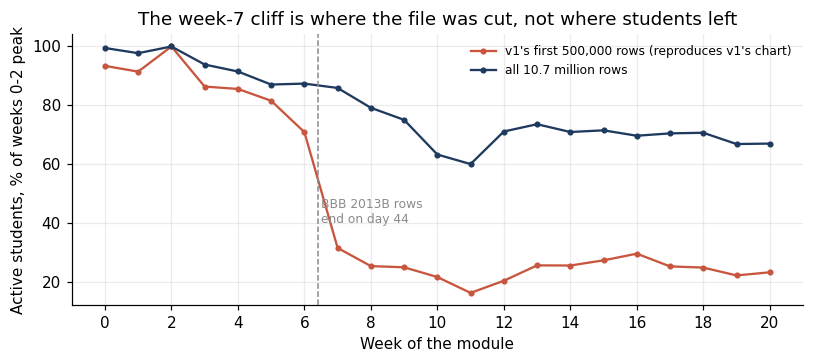

In [8]:
def weekly_active(d: pd.DataFrame) -> pd.Series:
    """v1's metric: students with any click in week w, relative to the busiest of weeks 0-2."""
    wk = d[(d["date"] >= 0) & (d["date"] <= 146)].assign(week=lambda x: x["date"] // 7)
    act = wk.groupby("week")["id_student"].nunique()
    return (act / act.iloc[:3].max() * 100).clip(upper=100)


samp, full = weekly_active(sample), weekly_active(daily)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(samp, marker="o", ms=3, color=WARM, label="v1's first 500,000 rows (reproduces v1's chart)")
ax.plot(full, marker="o", ms=3, color=INK, label="all 10.7 million rows")
ax.axvline(6.4, color=GREY, ls="--", lw=1)
ax.text(6.5, 40, "BBB 2013B rows\nend on day 44", fontsize=8, color=GREY)
ax.set_xlabel("Week of the module")
ax.set_xticks(range(0, 21, 2))
ax.set_ylabel("Active students, % of weeks 0-2 peak")
ax.set_title("The week-7 cliff is where the file was cut, not where students left")
ax.legend(frameon=False, fontsize=8)
save(fig, "week7_check.png")
R["sample_active_week6"], R["sample_active_week7"] = float(samp.loc[6]), float(samp.loc[7])
R["full_active_week6"], R["full_active_week7"] = float(full.loc[6]), float(full.loc[7])
print(f"v1's rows: week 6 {samp.loc[6]:.1f}% -> week 7 {samp.loc[7]:.1f}%;  all rows: {full.loc[6]:.1f}% -> {full.loc[7]:.1f}%")

v1's chart reproduces exactly from its 500,000 rows, and its cause is visible in the table above: those
rows hold module AAA's two presentations in full but only days -9 to 44 of BBB 2013B, whose 1,526
students make up most of the sample. After day 44 they simply stop appearing, which looks like 40% of
students vanishing in week 7. On all 10,655,280 rows, activity moves from 87.4% to 85.9% between weeks
6 and 7. **There is no week-7 cliff**, so the recommendation built on it ("maximum intervention push
in weeks 5-6") had no basis. The real timing of withdrawal is the subject of the next section.

## 3. When do students leave?

Withdrawal is a time-to-event outcome, so it is measured like one. Day 0 is the module start; a
student who completes the module is *censored* at its last day (we never see them withdraw).

10,063 dated withdrawals; 26.6% before day 0; median day 27


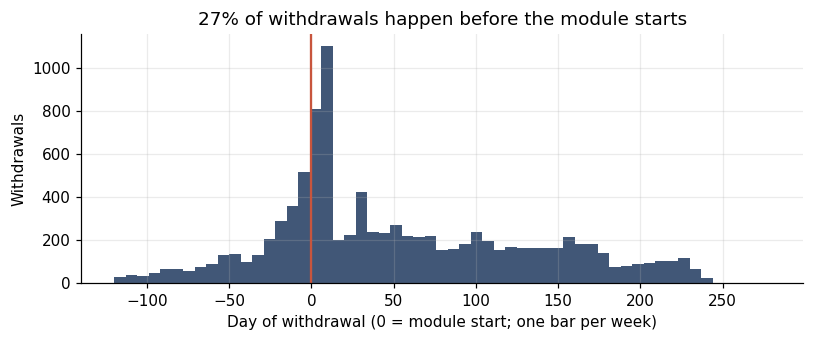

In [9]:
wdays = enrol[enrol["withdrawn"] == 1]["date_unregistration"]
R["withdrawals_dated"] = int(wdays.size)
R["withdrawals_before_day0"] = float((wdays < 0).mean())
R["withdrawal_median_day"] = float(wdays.median())
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.hist(wdays, bins=np.arange(-120, 280, 7), color=INK, alpha=0.85)
ax.axvline(0, color=WARM, lw=1.5)
ax.set_xlabel("Day of withdrawal (0 = module start; one bar per week)")
ax.set_ylabel("Withdrawals")
ax.set_title(f"{R['withdrawals_before_day0']:.0%} of withdrawals happen before the module starts")
save(fig, "withdrawal_days.png")
print(f"{R['withdrawals_dated']:,} dated withdrawals; {R['withdrawals_before_day0']:.1%} before day 0; median day {R['withdrawal_median_day']:.0f}")

More than a quarter of all withdrawals (26.6%) happen **before the module starts**, and half have
happened by day 27. Any early-warning system is racing the calendar: the most informative data
(marks, weeks of activity) arrives after most of the leaving is done.

The weekly hazard below asks a sharper question: of the students still enrolled at the start of week
w, what share leave during it?

      at_risk  events  hazard
week                         
0       29581     713  0.0241
1       29010    1068  0.0368
2       27976     214  0.0076
3       27793     360  0.0130
4       27441     303  0.0110
5       27141     216  0.0080
6       26928     246  0.0091
7       26684     256  0.0096
8       26429     230  0.0087
9       26200     220  0.0084
10      25981     203  0.0078
11      25778     146  0.0057


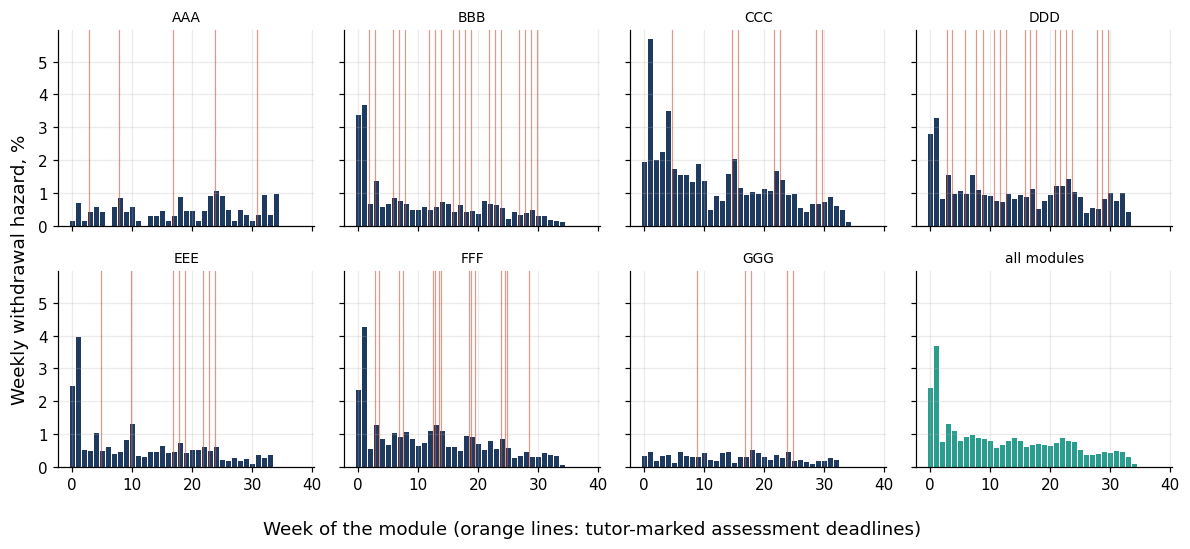

In [10]:
def life_table(e: pd.DataFrame, weeks=range(0, 39)) -> pd.DataFrame:
    """Weekly withdrawal hazard: withdrawals in week w divided by enrolments still registered at its start."""
    rows = []
    end = e["module_presentation_length"]
    for wk in weeks:
        a, b = 7 * wk, 7 * wk + 7
        at = e[(e["date_registration"].fillna(-1) < a) & (e["date_unregistration"].isna() | (e["date_unregistration"] >= a))
               & (end > a)]
        ev = at["date_unregistration"].between(a, b - 1).sum()
        rows.append({"week": wk, "at_risk": len(at), "events": int(ev), "hazard": ev / len(at) if len(at) else np.nan})
    return pd.DataFrame(rows).set_index("week")


lt = life_table(enrol)
due = T["assessments"][T["assessments"]["assessment_type"] == "TMA"].dropna(subset=["date"])
fig, axes = plt.subplots(2, 4, figsize=(11, 5), sharex=True, sharey=True)
for ax, (mod, e) in zip(axes.flat, enrol.groupby("code_module")):
    h = life_table(e)
    ax.bar(h.index, h["hazard"] * 100, color=INK, width=0.8)
    for d in due[due["code_module"] == mod]["date"].unique():
        ax.axvline(d / 7, color=WARM, lw=0.8, alpha=0.6)
    ax.set_title(f"{mod}", fontsize=9)
axes.flat[-1].bar(lt.index, lt["hazard"] * 100, color=ACCENT, width=0.8)
axes.flat[-1].set_title("all modules", fontsize=9)
fig.supxlabel("Week of the module (orange lines: tutor-marked assessment deadlines)")
fig.supylabel("Weekly withdrawal hazard, %")
save(fig, "hazard_by_module.png")
R["hazard_week0"], R["hazard_peak_week"] = float(lt.loc[0, "hazard"]), int(lt["hazard"].idxmax())
print(lt.head(12).round(4).to_string())

The hazard peaks in **weeks 0 and 1** (2.4% and 3.7% of enrolled students leave in those weeks), then
settles near 1% a week. CCC, the module v1 flagged, is high throughout, not just early. Some modules
show small rises just after a tutor-marked deadline (CCC around weeks 14 to 16, for instance), but
nothing like a single university-wide cliff.

{'AAA': 0.865, 'BBB': 0.786, 'CCC': 0.627, 'DDD': 0.704, 'EEE': 0.808, 'FFF': 0.751, 'GGG': 0.909} log-rank chi2 873; 1 withdrawals dated after the module ended


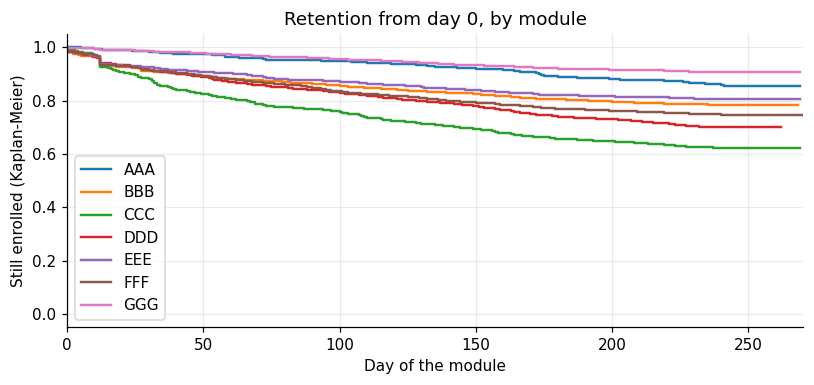

In [11]:
start = enrol[(enrol["date_unregistration"].isna()) | (enrol["date_unregistration"] >= 0)].copy()
start["T"] = np.where(start["withdrawn"] == 1, start["date_unregistration"], start["module_presentation_length"])
fig, ax = plt.subplots(figsize=(7.5, 3.6))
kmf = KaplanMeierFitter()
for mod, e in start.groupby("code_module"):
    kmf.fit(e["T"], e["withdrawn"], label=mod)
    kmf.plot_survival_function(ax=ax, ci_show=False, lw=1.6)
ax.set_xlabel("Day of the module")
ax.set_ylabel("Still enrolled (Kaplan-Meier)")
ax.set_title("Retention from day 0, by module")
save(fig, "km_by_module.png")
ax.set_xlim(0, 270)
lr_test = multivariate_logrank_test(start["T"], start["code_module"], start["withdrawn"])
R["logrank_chi2"], R["logrank_p"] = float(lr_test.test_statistic), float(lr_test.p_value)
# Some withdrawals are dated after the module's last day; a Kaplan-Meier curve's final value then means
# nothing, so modules are compared at a common horizon, day 230 (every module runs at least 234 days).
late = start[(start["withdrawn"] == 1) & (start["T"] > start["module_presentation_length"])]
R["withdrawals_after_module_end"] = len(late)
km230 = {m: float(KaplanMeierFitter().fit(e["T"], e["withdrawn"]).predict(230)) for m, e in start.groupby("code_module")}
R["km_retained_day230_by_module"] = km230
print({m: round(v, 3) for m, v in km230.items()}, f"log-rank chi2 {lr_test.test_statistic:.0f};",
      f"{len(late)} withdrawals dated after the module ended")

Among students enrolled on day 0, the share still enrolled on day 230 ranges from 90.9% (GGG) to
62.7% (CCC); the modules' curves differ far beyond chance (log-rank chi-squared 873 on 6 degrees of
freedom). One withdrawal is dated after its module ended, which is why the comparison uses day 230
rather than each curve's last point.

## 4. Early warning on day *k*

**Design.** For each cutoff k in {0, 14, 28, 56, 84} days, the at-risk set is every enrolment still
registered on day k; the label is whether it ends in withdrawal; features use only data dated before
day k (see `src/oulad_ew.py`). Models are trained on the 2013B, 2013J and 2014B presentations and tested
on **2014J**, the last presentation in the data: the realistic case of training on past cohorts and
scoring the next one. Model settings were fixed before looking at the test set.

**Contenders.** (1) the module's historical withdrawal rate; (2) an inactivity rule: days since the last
click; (3) logistic regression; (4) gradient-boosted trees.

In [12]:
K = [0, 14, 28, 56, 84]
FRAMES = {k: ew.features_at(T, enrol, daily, k) for k in K}


def lr_model(k):
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)), ("sc", StandardScaler())]), ew.numeric_features(k)),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ew.STATIC_CAT)])
    return Pipeline([("pre", pre), ("m", LogisticRegression(max_iter=4000, C=1.0))])


def gb_model(k):
    pre = ColumnTransformer([("num", "passthrough", ew.numeric_features(k)),
                             ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ew.STATIC_CAT)])
    return Pipeline([("pre", pre), ("m", HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05, max_leaf_nodes=31,
                                                                         l2_regularization=1.0, random_state=SEED))])


def top_frac(y, s, frac=0.10):
    n = int(np.ceil(frac * len(s)))
    idx = np.argsort(-s, kind="stable")[:n]
    return y[idx].mean(), y[idx].sum() / y.sum()


def boot_auc(y, scores: dict, n=1000):
    rng = np.random.default_rng(SEED)
    out = {m: [] for m in scores}
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if y[i].min() == y[i].max():
            continue
        for m, s in scores.items():
            out[m].append(roc_auc_score(y[i], s[i]))
    return {m: np.percentile(v, [2.5, 97.5]) for m, v in out.items()}, out


rows, PRED = [], {}
for k in K:
    f = FRAMES[k]
    tr, te = f[f["code_presentation"] != TEST_PRES], f[f["code_presentation"] == TEST_PRES]
    y = te["withdrawn"].to_numpy()
    base = tr.groupby("code_module")["withdrawn"].mean()
    scores = {"module rate": te["code_module"].map(base).to_numpy(), "inactivity rule": te["days_since_active"].to_numpy()}
    for name, mk in (("logistic", lr_model), ("boosted trees", gb_model)):
        m = mk(k).fit(tr, tr["withdrawn"])
        scores[name] = m.predict_proba(te)[:, 1]
        if name == "boosted trees":
            PRED[k] = (te, scores[name], m)
    ci, dist = boot_auc(y, scores)
    for name, s in scores.items():
        p10, r10 = top_frac(y, s)
        rows.append({"k": k, "model": name, "train_n": len(tr), "test_n": len(te), "base_rate": y.mean(),
                     "auc": roc_auc_score(y, s), "auc_lo": ci[name][0], "auc_hi": ci[name][1],
                     "pr_auc": average_precision_score(y, s),
                     "brier": brier_score_loss(y, s) if name in ("logistic", "boosted trees", "module rate") else np.nan,
                     "precision_top10": p10, "recall_top10": r10})
    d = np.array(dist["boosted trees"]) - np.array(dist["logistic"])
    R[f"gb_minus_lr_auc_ci_k{k}"] = [float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))]
res = pd.DataFrame(rows)
res.to_csv(ROOT / "results" / "early_warning_by_day.csv", index=False)
show = res.pivot_table(index="k", columns="model", values="auc").round(3)
print(show.to_string())
print(res[res["model"] == "boosted trees"][["k", "test_n", "base_rate", "auc", "auc_lo", "auc_hi", "pr_auc", "brier",
                                            "precision_top10", "recall_top10"]].round(3).to_string(index=False))

model  boosted trees  inactivity rule  logistic  module rate
k                                                           
0              0.697            0.594     0.699        0.592
14             0.672            0.560     0.671        0.608
28             0.669            0.572     0.667        0.604
56             0.699            0.607     0.691        0.595
84             0.699            0.585     0.690        0.602
 k  test_n  base_rate   auc  auc_lo  auc_hi  pr_auc  brier  precision_top10  recall_top10
 0   10147      0.278 0.697   0.684   0.708   0.471  0.182            0.562         0.202
14    9247      0.198 0.672   0.659   0.687   0.346  0.149            0.415         0.209
28    9127      0.186 0.669   0.654   0.684   0.335  0.142            0.399         0.215
56    8792      0.155 0.699   0.684   0.713   0.313  0.121            0.357         0.231
84    8484      0.124 0.699   0.683   0.715   0.258  0.102            0.297         0.240


**What the table says.** On the next cohort (2014J), the honest models reach ROC-AUC between 0.67 and
0.70 depending on the day. Three things stand out:

- **The score does not simply rise with time.** It dips from day 0 (0.697) to day 28 (0.669) and
  recovers by day 56 (0.699). The population changes underneath: on day 0 the at-risk set still holds
  the students who will leave in weeks 0 and 1, who are comparatively easy to spot; by day 28 they are
  gone and the remaining leavers are harder, until marks accumulate.
- **Logistic regression matches the boosted trees.** The bootstrap interval for the difference covers
  zero on four of the five days. For a tool tutors must trust, the simpler model is the better choice.
- **Simple baselines are weak.** The module's historical rate and the inactivity rule sit near 0.6.

These are modest numbers, and they are the true ones. The next two cells show where the ceiling comes
from.

### The honest rung of the ladder

The day-28 model, on students still enrolled on day 28, tested on the next cohort. To compare like
with like, it is also scored with v1's own Random Forest.

                                                                                       step   auc
                                 A. v1 as published: features per student, random row split 0.896
                                       B. features per enrolment (no mixing across modules) 0.932
                                                                     C. B, split by student 0.932
                                                  D. B, train on 2013B-2014B, test on 2014J 0.942
E. honest: day-28 features, students enrolled on day 28, test on 2014J (v1's Random Forest) 0.662
                                                            F. as E, gradient-boosted trees 0.669
share of v1's lift above a coin toss that came from reading the future: 59%


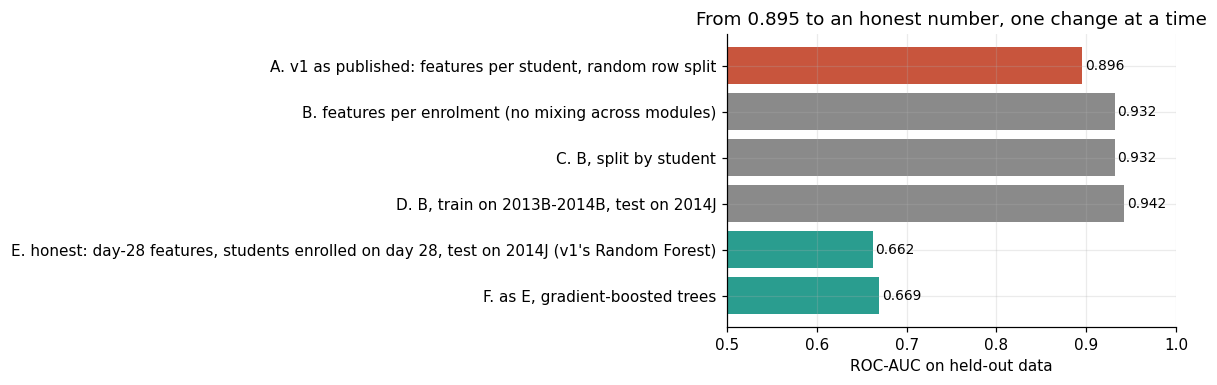

In [13]:
f28 = FRAMES[28]
tr, te = f28[f28["code_presentation"] != TEST_PRES], f28[f28["code_presentation"] == TEST_PRES]
pre = ColumnTransformer([("num", SimpleImputer(strategy="median"), ew.numeric_features(28)),
                         ("cat", OneHotEncoder(handle_unknown="ignore"), ew.STATIC_CAT)])
rf28 = Pipeline([("pre", pre), ("m", rf())]).fit(tr, tr["withdrawn"])
ladder.append(("E. honest: day-28 features, students enrolled on day 28, test on 2014J (v1's Random Forest)",
               roc_auc_score(te["withdrawn"], rf28.predict_proba(te)[:, 1])))
gb28 = res[(res["k"] == 28) & (res["model"] == "boosted trees")].iloc[0]
ladder.append(("F. as E, gradient-boosted trees", gb28["auc"]))
lad = pd.DataFrame(ladder, columns=["step", "auc"])
lad.to_csv(ROOT / "results" / "leakage_ladder.csv", index=False)
print(lad.round(3).to_string(index=False))
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.barh(lad["step"][::-1], lad["auc"][::-1], color=[ACCENT, ACCENT] + [GREY] * 3 + [WARM])
for i, v in enumerate(lad["auc"][::-1]):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("ROC-AUC on held-out data")
ax.set_title("From 0.895 to an honest number, one change at a time")
save(fig, "leakage_ladder.png")
R["ladder"] = {r.step: float(r.auc) for r in lad.itertuples()}
R["share_of_v1_lift_from_leak"] = float((lad["auc"].iloc[0] - lad["auc"].iloc[4]) / (lad["auc"].iloc[0] - 0.5))
print(f"share of v1's lift above a coin toss that came from reading the future: {R['share_of_v1_lift_from_leak']:.0%}")

Same Random Forest as v1, same kind of features, but restricted to what was observable on day 28 for
students still enrolled then: **0.662**. Gradient-boosted trees: 0.669. Of v1's lift above a coin toss
(0.896 minus 0.5), about three-fifths (59%) was the model reading the future.

### Is the target the problem?

v1 counted a student who **fails** as "retained". Behaviourally, failing and withdrawing look alike:
both disengage and miss work. A model asked to separate them from each other is being asked something
the data barely contains. Three definitions, same features, same split, gradient-boosted trees:

- **withdraw vs everyone else** (v1's definition, used so far);
- **withdraw vs pass** (fails removed from both training and test, the usual research set-up);
- **not passing** (withdraw or fail) **vs pass**: the outcome a student-support team cares about.

target  not passing (withdraw or fail) vs pass  withdraw vs everyone else  withdraw vs pass (fails removed)
k                                                                                                          
0                                        0.717                      0.697                             0.735
14                                       0.727                      0.672                             0.724
28                                       0.725                      0.669                             0.714
56                                       0.784                      0.699                             0.767
84                                       0.810                      0.699                             0.779
 k                                 target  test_n  base_rate   auc  precision_top10
28              withdraw vs everyone else    9127      0.186 0.669            0.399
28       withdraw vs pass (fails removed)    7152      0.237 0.714          

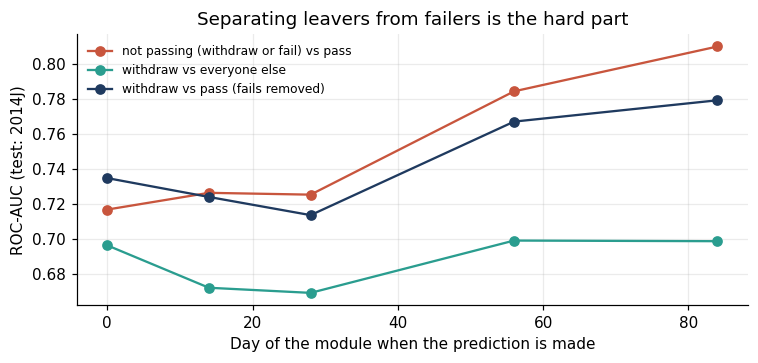

In [14]:
trows = []
for k in K:
    f = FRAMES[k].copy()
    f["not_passing"] = f["final_result"].isin(["Withdrawn", "Fail"]).astype(int)
    variants = {"withdraw vs everyone else": (f, "withdrawn"),
                "withdraw vs pass (fails removed)": (f[f["final_result"] != "Fail"], "withdrawn"),
                "not passing (withdraw or fail) vs pass": (f, "not_passing")}
    for name, (d, target) in variants.items():
        tr, te = d[d["code_presentation"] != TEST_PRES], d[d["code_presentation"] == TEST_PRES]
        s = gb_model(k).fit(tr, tr[target]).predict_proba(te)[:, 1]
        p10, r10 = top_frac(te[target].to_numpy(), s)
        trows.append({"k": k, "target": name, "test_n": len(te), "base_rate": te[target].mean(),
                      "auc": roc_auc_score(te[target], s), "precision_top10": p10})
tgt = pd.DataFrame(trows)
tgt.to_csv(ROOT / "results" / "target_definitions.csv", index=False)
print(tgt.pivot_table(index="k", columns="target", values="auc").round(3).to_string())
print(tgt[tgt["k"] == 28].round(3).to_string(index=False))
for _, r in tgt.iterrows():
    R[f"auc_k{r.k}_{r.target.split(' ')[0]}_{'nofail' if 'removed' in r.target else 'all'}"] = float(r.auc)
fig, ax = plt.subplots(figsize=(7, 3.4))
for (name, d), c in zip(tgt.groupby("target"), (WARM, ACCENT, INK)):
    ax.plot(d["k"], d["auc"], marker="o", color=c, label=name)
ax.set_xlabel("Day of the module when the prediction is made")
ax.set_ylabel("ROC-AUC (test: 2014J)")
ax.set_title("Separating leavers from failers is the hard part")
ax.legend(frameon=False, fontsize=8)
save(fig, "target_definitions.png")

With the same features, asking **"who will not pass?"** instead of "who will withdraw?" lifts day-28
AUC from 0.669 to 0.725, and to 0.810 by day 84; removing failing students from the data (0.714 on day
28) shows the same thing from the other side. Much of the ceiling in v1's framing is a definitional
choice: failing and withdrawing students behave alike in the data, and a student-support team would
want to reach both. **The recommended target for a real system is "not passing".** Withdrawal is kept
throughout only so that v1 and v2 can be compared like for like.

### The earliness-accuracy trade-off

Waiting improves the prediction, but every week some of the students you wanted to help have already
gone. The second line counts, among all eventual withdrawals, the share still enrolled (and so still
reachable) on day k.

{0: 0.734, 14: 0.557, 28: 0.5, 56: 0.398, 84: 0.319}


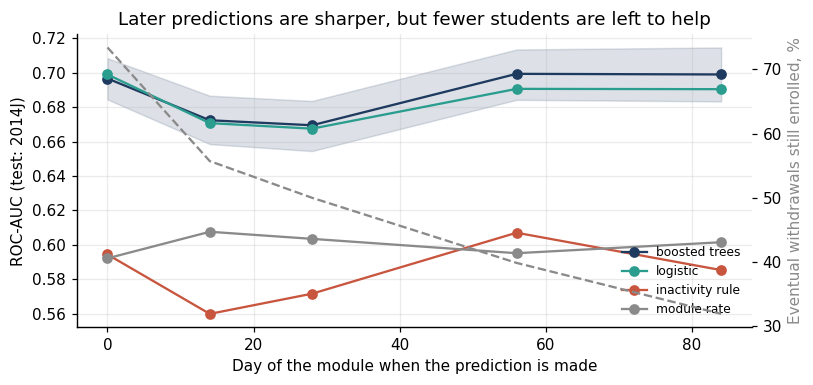

In [15]:
catch = {k: float((wdays >= k).mean()) for k in K}
R["reachable_share_by_day"] = catch
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for name, c in (("boosted trees", INK), ("logistic", ACCENT), ("inactivity rule", WARM), ("module rate", GREY)):
    s = res[res["model"] == name].set_index("k")
    ax.plot(s.index, s["auc"], marker="o", color=c, label=name)
    if name == "boosted trees":
        ax.fill_between(s.index, s["auc_lo"], s["auc_hi"], color=c, alpha=0.15)
ax.set_xlabel("Day of the module when the prediction is made")
ax.set_ylabel("ROC-AUC (test: 2014J)")
ax2 = ax.twinx()
ax2.plot(list(catch), [v * 100 for v in catch.values()], ls="--", color=GREY)
ax2.set_ylabel("Eventual withdrawals still enrolled, %", color=GREY)
ax2.grid(False)
ax.legend(frameon=False, loc="lower right", fontsize=8)
ax.set_title("Later predictions are sharper, but fewer students are left to help")
save(fig, "earliness_tradeoff.png")
print({k: round(v, 3) for k, v in catch.items()})

On day 0, 73.4% of eventual withdrawals are still enrolled; by day 28 only half are; by day 84, under a
third. A model that is perfect on day 84 can reach at most a third of the students it exists to help.
**The design question is not "which day gives the best AUC?" but "how many students can we still reach,
and how sure do we need to be?"**, which is why the next section measures capacity, not accuracy.

### Day 28 in detail: curves, calibration, capacity and lead time

{'day28_calibration_max_gap': 0.068, 'day28_top10_recall': 0.215, 'day28_top10_precision': 0.399, 'day28_rule_top10_recall': 0.124, 'day28_top20_recall': 0.357, 'day28_top20_precision': 0.331, 'day28_rule_top20_recall': 0.264, 'day28_lead_days_median': 61.5, 'day28_lead_days_q1': 25.75, 'day28_lead_days_q3': 123.25, 'day28_test_n': 9127, 'day28_base_rate': 0.186}


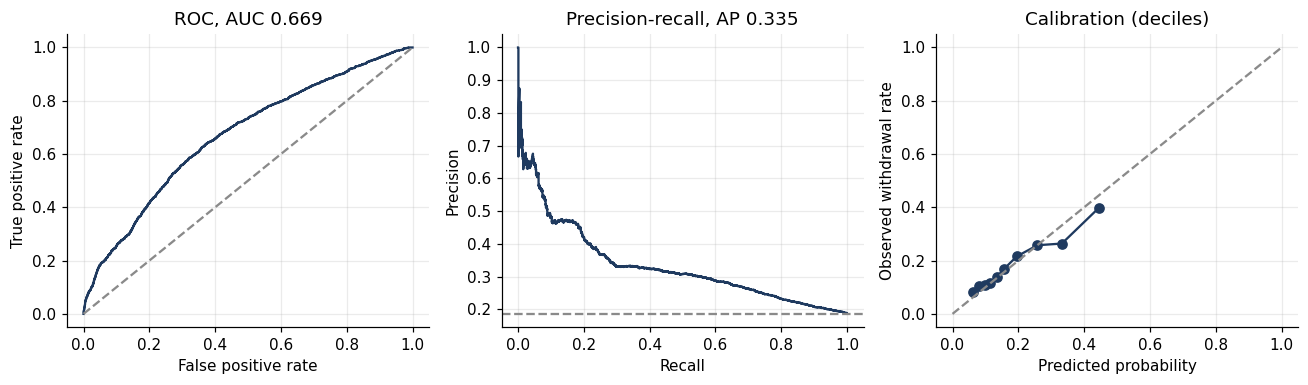

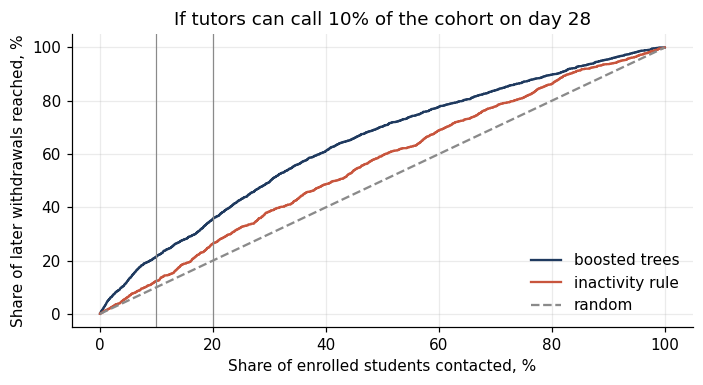

In [16]:
te28, s28, m28 = PRED[28]
y28 = te28["withdrawn"].to_numpy()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
fpr, tpr, _ = roc_curve(y28, s28)
axes[0].plot(fpr, tpr, color=INK)
axes[0].plot([0, 1], [0, 1], color=GREY, ls="--")
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title=f"ROC, AUC {roc_auc_score(y28, s28):.3f}")
pr, rc, _ = precision_recall_curve(y28, s28)
axes[1].plot(rc, pr, color=INK)
axes[1].axhline(y28.mean(), color=GREY, ls="--")
axes[1].set(xlabel="Recall", ylabel="Precision", title=f"Precision-recall, AP {average_precision_score(y28, s28):.3f}")
pt, pp = calibration_curve(y28, s28, n_bins=10, strategy="quantile")
axes[2].plot(pp, pt, marker="o", color=INK)
axes[2].plot([0, 1], [0, 1], color=GREY, ls="--")
axes[2].set(xlabel="Predicted probability", ylabel="Observed withdrawal rate", title="Calibration (deciles)")
save(fig, "day28_curves.png")
R["day28_calibration_max_gap"] = float(np.max(np.abs(pp - pt)))

order = np.argsort(-s28, kind="stable")
frac = np.arange(1, len(order) + 1) / len(order)
gain = np.cumsum(y28[order]) / y28.sum()
rule_order = np.argsort(-te28["days_since_active"].to_numpy(), kind="stable")
rule_gain = np.cumsum(y28[rule_order]) / y28.sum()
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(frac * 100, gain * 100, color=INK, label="boosted trees")
ax.plot(frac * 100, rule_gain * 100, color=WARM, label="inactivity rule")
ax.plot([0, 100], [0, 100], color=GREY, ls="--", label="random")
for c in (10, 20):
    ax.axvline(c, color=GREY, lw=0.8)
ax.set(xlabel="Share of enrolled students contacted, %", ylabel="Share of later withdrawals reached, %",
       title="If tutors can call 10% of the cohort on day 28")
ax.legend(frameon=False)
save(fig, "day28_capacity.png")
for c in (0.10, 0.20):
    n = int(np.ceil(c * len(order)))
    R[f"day28_top{int(c * 100)}_recall"] = float(gain[n - 1])
    R[f"day28_top{int(c * 100)}_precision"] = float(y28[order[:n]].mean())
    R[f"day28_rule_top{int(c * 100)}_recall"] = float(rule_gain[n - 1])
flagged = te28.iloc[order[: int(np.ceil(0.1 * len(order)))]]
tp = flagged[flagged["withdrawn"] == 1]
lead = tp["date_unregistration"] - 28
R["day28_lead_days_median"], R["day28_lead_days_q1"], R["day28_lead_days_q3"] = (float(lead.median()), float(lead.quantile(.25)),
                                                                                    float(lead.quantile(.75)))
R["day28_test_n"], R["day28_base_rate"] = len(te28), float(y28.mean())
print({k: round(v, 3) for k, v in R.items() if k.startswith("day28")})

**Day 28, on the 9,127 students of 2014J still enrolled.** Their eventual withdrawal rate is 18.6%.

- **Capacity.** If tutors can contact 10% of the cohort, the model's list is 39.9% eventual leavers,
  2.1 times the base rate, and it reaches 21.5% of all of them; the inactivity rule reaches 12.4%. At
  20% capacity: 35.7% reached, against 26.4% for the rule.
- **Lead time.** The flagged students who did leave did so a median 61.5 days later (middle half: 26 to
  123 days). There is time to act.
- **Calibration.** Predicted and observed rates stay within 6.8 points across the ten risk deciles, so a
  predicted 40% means roughly 40%: usable for planning caseloads, not only for ranking.
- **Precision-recall.** Average precision 0.335 against a base rate of 0.186: real lift, but four in ten
  flagged students would not have left. Outreach has to be supportive, never punitive.

### What the model relies on

Permutation importance on the 2014J test set: how much the AUC drops when one feature is shuffled.
This describes the model, not the causes of withdrawal.

mean_score           0.0469
n_missed             0.0301
code_module          0.0131
log_clicks_rel       0.0079
days_since_active    0.0057
studied_credits      0.0046
disability           0.0043
edu_ord              0.0034
n_late               0.0032
imd_ord              0.0021


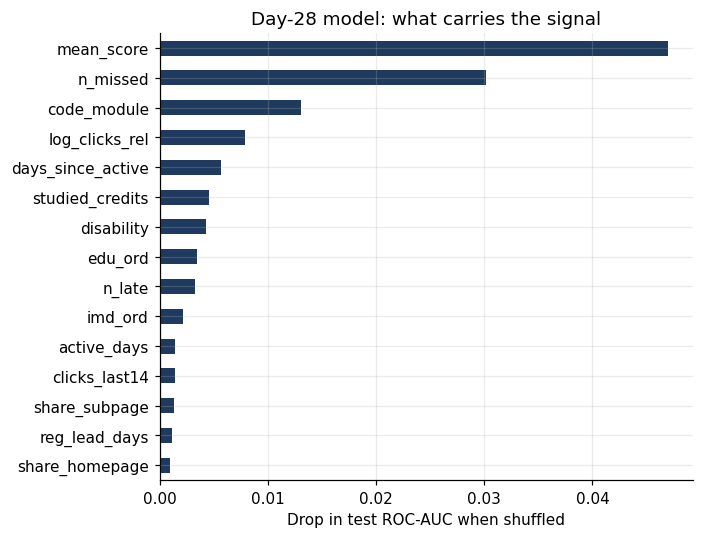

In [17]:
num28 = ew.numeric_features(28)
pi = permutation_importance(m28, te28[num28 + ew.STATIC_CAT], y28, scoring="roc_auc", n_repeats=10, random_state=SEED, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=num28 + ew.STATIC_CAT).sort_values()
fig, ax = plt.subplots(figsize=(6.5, 5))
imp.tail(15).plot.barh(ax=ax, color=INK)
ax.set_xlabel("Drop in test ROC-AUC when shuffled")
ax.set_title("Day-28 model: what carries the signal")
save(fig, "day28_importance.png")
R["day28_top_features"] = imp.sort_values(ascending=False).head(6).round(4).to_dict()
print(imp.sort_values(ascending=False).head(10).round(4).to_string())

The first marks carry most of the signal (shuffling the mean score costs 0.047 of AUC), followed by
missed deadlines (0.030), the module (0.013) and engagement relative to classmates (0.008). Demographics
add little once behaviour is known, which is what v1 concluded too; that conclusion holds.

## 5. Who gets flagged: error rates across groups

An outreach list is a decision about people. On day 28 the top 10% by risk are flagged; within each
group we compare the withdrawal rate, the model's AUC, the share of the group flagged, recall, and
calibration-in-the-large (mean predicted minus observed).

In [18]:
te28 = te28.assign(score=s28, flag=0)
te28.iloc[order[: int(np.ceil(0.1 * len(order)))], te28.columns.get_loc("flag")] = 1
te28["imd_quintile"] = pd.cut(te28["imd_ord"], [-1, 1, 3, 5, 7, 9], labels=["most deprived", "2", "3", "4", "least deprived"])
groups = []
for col in ["imd_quintile", "disability", "age_band", "gender"]:
    for g, d in te28.groupby(col, observed=True):
        if d["withdrawn"].nunique() < 2 or len(d) < 100:
            continue
        groups.append({"attribute": col, "group": str(g), "n": len(d), "withdrawal_rate": d["withdrawn"].mean(),
                       "auc": roc_auc_score(d["withdrawn"], d["score"]), "flagged_share": d["flag"].mean(),
                       "recall": d.loc[d["withdrawn"] == 1, "flag"].mean(),
                       "precision": d.loc[d["flag"] == 1, "withdrawn"].mean() if d["flag"].sum() else np.nan,
                       "calibration_gap": d["score"].mean() - d["withdrawn"].mean()})
fair = pd.DataFrame(groups)
fair.to_csv(ROOT / "results" / "day28_groups.csv", index=False)
print(fair.round(3).to_string(index=False))

   attribute          group    n  withdrawal_rate   auc  flagged_share  recall  precision  calibration_gap
imd_quintile  most deprived 1710            0.208 0.678          0.123   0.242      0.408           -0.004
imd_quintile              2 1929            0.202 0.661          0.109   0.206      0.379           -0.008
imd_quintile              3 1834            0.187 0.679          0.111   0.236      0.397            0.004
imd_quintile              4 1743            0.168 0.667          0.090   0.215      0.404            0.013
imd_quintile least deprived 1546            0.168 0.650          0.071   0.162      0.382            0.007
  disability              N 8286            0.178 0.666          0.091   0.200      0.389            0.005
  disability              Y  841            0.262 0.667          0.184   0.314      0.445           -0.027
    age_band           0-35 6247            0.187 0.672          0.106   0.224      0.395            0.008
    age_band          35-55 2793     

- **Deprivation and disability.** The most deprived fifth is flagged at 12.3% against 7.1% for the least
  deprived, and disabled students at 18.4% against 9.1%. Both track real differences in withdrawal
  (20.8% vs 16.8%; 26.2% vs 17.8%), and calibration stays within 3 points in every group, so the list
  follows risk rather than inventing it. Disabled students' risk is slightly *under*-predicted (by 2.7
  points), the direction that harms them.
- **Gender.** The model separates leavers from stayers better for men (AUC 0.697) than for women
  (0.634), and its flags are right 47.6% of the time for men against 30.9% for women. Women's
  withdrawals seem less visible in clicks and marks; the data cannot say why. A deployment should report
  this gap rather than hide it, and should not use the model to *ration* support between groups.

## 6. Module effects, adjusted for who enrols

v1 reported withdrawal ranging from 11.5% (GGG) to 44.5% (CCC) and recommended auditing CCC. Modules
attract different students, so the raw gap mixes course design with intake. A logistic regression on
everything known at registration (age, education, deprivation, previous attempts, credits, disability,
gender, how early they registered, and the presentation's start month) gives adjusted rates: the
average predicted withdrawal if every enrolment were in that module.

       raw  adjusted
GGG  0.114     0.184
AAA  0.168     0.181
EEE  0.245     0.289
BBB  0.301     0.278
FFF  0.307     0.291
DDD  0.357     0.345
CCC  0.442     0.443


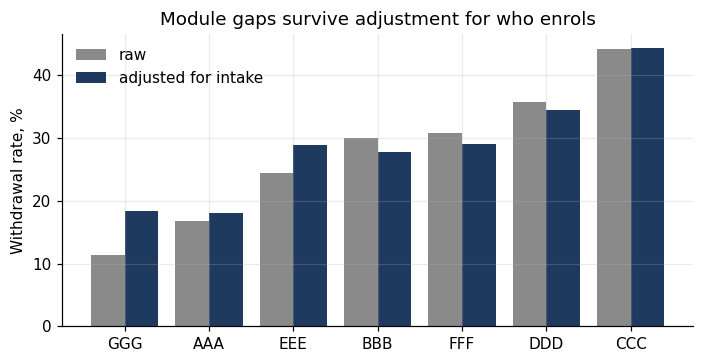

In [19]:
d0 = enrol.copy()
d0["imd_ord"] = d0["imd_ord"].fillna(d0["imd_ord"].median())
d0["reg_lead_days"] = d0["reg_lead_days"].fillna(d0["reg_lead_days"].median())
d0["start_month"] = d0["code_presentation"].str[-1]
d0["year"] = d0["code_presentation"].str[:4]
fit = smf.logit("withdrawn ~ C(code_module) + age_ord + edu_ord + imd_ord + num_of_prev_attempts + np.log(studied_credits)"
                " + C(disability) + C(gender) + reg_lead_days + C(start_month) + C(year)", data=d0).fit(disp=0)
adj = {}
for mod in sorted(d0["code_module"].unique()):
    adj[mod] = float(fit.predict(d0.assign(code_module=mod)).mean())
raw = d0.groupby("code_module")["withdrawn"].mean()
mods = pd.DataFrame({"raw": raw, "adjusted": pd.Series(adj)}).sort_values("raw")
mods.to_csv(ROOT / "results" / "module_rates.csv")
R["module_raw"], R["module_adjusted"] = mods["raw"].to_dict(), mods["adjusted"].to_dict()
print(mods.round(3).to_string())
fig, ax = plt.subplots(figsize=(6.5, 3.4))
x = np.arange(len(mods))
ax.bar(x - 0.2, mods["raw"] * 100, 0.4, color=GREY, label="raw")
ax.bar(x + 0.2, mods["adjusted"] * 100, 0.4, color=INK, label="adjusted for intake")
ax.set_xticks(x, mods.index)
ax.set_ylabel("Withdrawal rate, %")
ax.set_title("Module gaps survive adjustment for who enrols")
ax.legend(frameon=False)
save(fig, "module_adjusted.png")

CCC's 44.2% is not explained by who enrols (44.3% adjusted), so v1's call to look at CCC's design
survives. GGG's low rate is partly its intake: 11.4% raw, 18.4% once its students are made comparable.
The spread between the best and worst module narrows from 33 to 26 points but stays large. Adjustment
removes measured differences in intake, not unmeasured ones (motivation, workload outside study), so
this narrows the question for CCC rather than answering it.

## 7. Conclusions, limits and the numbers worth quoting

**What changed from v1**

| v1 claim | What the evidence supports |
|---|---|
| ROC-AUC 0.895 | 0.669 on day 28, on students still enrolled, tested on a later cohort; 0.725 for "not passing" |
| 32,593 students | 32,593 enrolments held by 28,785 students |
| Never-submitters withdraw at 79.5% | Mostly reverse causation: 79% of the never-submitters who withdrew had left before their first assessment was due. Forward version: missing the first deadline means 31.8% later withdraw vs 13.4% (2.4 times) |
| A week-7 cliff (active students fall 39 points) | An artefact of reading the first 500,000 rows; on all rows activity falls 1.5 points |
| Module CCC 44.5% vs GGG 11.5% | Holds for CCC after adjusting for intake; GGG's advantage is partly who enrols |
| Behaviour beats demographics | Holds |

**What a university could deploy.** A weekly risk list from day 14, with the target "not passing",
logistic regression for transparency, sized to tutor capacity (the top 10% on day 28 is 2.1 times as
likely to leave as average), plus the first-deadline alert. Every flag needs a supportive response.

**Limits.** One university, 2013 and 2014; one test cohort (2014J); reasons for leaving are not
recorded; scores are treated as known on submission (OULAD does not record when marks were
returned); none of this says an intervention would work, only whom it should reach first.

In [20]:
(ROOT / "results" / "metrics.json").write_text(json.dumps(R, indent=1, default=float))
print(json.dumps({k: v for k, v in R.items() if not isinstance(v, dict)}, indent=1, default=float))

{
 "enrolments": 32593,
 "students": 28785,
 "presentations": 22,
 "withdrawn_rate_all": 0.3116006504464149,
 "dropped_withdrawn_without_date": 93,
 "dropped_unregistered_but_not_withdrawn": 9,
 "enrolments_kept": 32491,
 "click_rows": 10655280,
 "v1_auc_reproduced": 0.8958063452317949,
 "v1_students_in_both_splits": 1121,
 "corr_withdrawal_day_num_assessments": 0.7185679404333288,
 "v1_never_submitted_students": 5847,
 "v1_never_submitted_withdrawn_share": 0.7949375748246964,
 "never_submitted_enrolments": 6750,
 "never_submitted_withdrawn_share": 0.8093333333333333,
 "never_submitted_left_before_first_due": 0.7944352919641223,
 "never_submitted_left_before_day0": 0.4845323082555372,
 "first_deadline_enrolled": 27782,
 "first_deadline_missed": 8951,
 "first_deadline_missed_withdraw_rate": 0.31840017875097754,
 "first_deadline_met_withdraw_rate": 0.1340343051351495,
 "v1_sample_enrolment_share": 0.07716380817967049,
 "v1_sample_bbb_last_day": 44,
 "sample_active_week6": 70.933734939759